In [1]:
# Use Python 3.12.3

import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
# seasons = range(2006, 2024)     #Passing stats started in 2006
pbp_py = nfl.import_pbp_data([2023])

2023 done.
Downcasting floats.


<h2>Cleaning Data</h2>

In [3]:
#Select relevant features
game_situation = ["yardline_100", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive", "qtr", "down", "ydstogo", "score_differential"] 
offensive = ["offense_formation", "offense_personnel"]
defensive = ["defenders_in_box", "defense_personnel"]
play_type = ["play_type", "run_location", "run_gap", "pass_location", "pass_length"]

df = pbp_py[game_situation + offensive + defensive + play_type]

# Drop plays that aren't run or pass plays
df = df.dropna(subset=["play_type"]).reset_index(drop=True)
df = df.loc[df['play_type'].isin(['run', 'pass'])]
len(df)

df_combined = df.copy()

# Put together offensive play call
def combine_columns(row):
    if row['play_type'] == 'run':
        return f"{row['play_type']}_{row['run_location']}_{row['run_gap']}"
    elif row['play_type'] == 'pass':
        return f"{row['play_type']}_{row['pass_location']}_{row['pass_length']}"
    else:
        return None

#Combine the necessary parts of the offensive play together
df_combined['offensive_play'] = df_combined.apply(combine_columns, axis=1)

# Remove plays that result in successful defensive stop
df_combined = df_combined[~df_combined['offensive_play'].isin(['pass_None_None', 'run_None_None', 'run_right_None', 'run_middle_None', 'run_left_None'])]
len(df_combined)

30000

From defensive perspective, predicting what the offense is going to run based on situational context (time remaining, downs, distance) and offensive formation

In [4]:
df_combined.groupby("offensive_play").count()

# Replace NaN with 0
df_combined = df_combined.fillna(0)
df_combined.head(10)

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,score_differential,offense_formation,offense_personnel,defenders_in_box,defense_personnel,play_type,run_location,run_gap,pass_location,pass_length,offensive_play
1,75.0,900.0,1800.0,3600.0,1.0,1.0,1.0,10.0,0.0,SHOTGUN,"1 RB, 2 TE, 2 WR",7.0,"3 DL, 4 LB, 4 DB",run,right,tackle,0,0,run_right_tackle
2,72.0,870.0,1770.0,3570.0,1.0,1.0,2.0,7.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",pass,0,0,right,short,pass_right_short
3,66.0,835.0,1735.0,3535.0,1.0,1.0,3.0,1.0,0.0,I_FORM,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",run,left,guard,0,0,run_left_guard
4,64.0,796.0,1696.0,3496.0,1.0,1.0,1.0,10.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",pass,0,0,middle,short,pass_middle_short
5,64.0,792.0,1692.0,3492.0,1.0,1.0,2.0,10.0,0.0,SINGLEBACK,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",pass,0,0,middle,short,pass_middle_short
6,52.0,754.0,1654.0,3454.0,1.0,1.0,1.0,10.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",pass,0,0,left,short,pass_left_short
7,51.0,716.0,1616.0,3416.0,1.0,1.0,2.0,9.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",pass,0,0,left,short,pass_left_short
8,51.0,711.0,1611.0,3411.0,1.0,1.0,3.0,9.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"1 DL, 5 LB, 5 DB",pass,0,0,right,short,pass_right_short
10,83.0,659.0,1559.0,3359.0,2.0,1.0,1.0,10.0,0.0,SINGLEBACK,"1 RB, 1 TE, 3 WR",6.0,"4 DL, 2 LB, 5 DB",run,left,end,0,0,run_left_end
11,84.0,628.0,1528.0,3328.0,2.0,1.0,2.0,11.0,0.0,SINGLEBACK,"1 RB, 2 TE, 2 WR",7.0,"4 DL, 2 LB, 5 DB",run,left,guard,0,0,run_left_guard


In [5]:
df_combined.groupby(by="offensive_play").count()

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,score_differential,offense_formation,offense_personnel,defenders_in_box,defense_personnel,play_type,run_location,run_gap,pass_location,pass_length
offensive_play,,,,,,,,,,,,,,,,,,
pass_left_deep,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417
pass_left_short,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994
pass_middle_deep,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621
pass_middle_short,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144
pass_right_deep,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448
pass_right_short,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560
run_left_end,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048
run_left_guard,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756
run_left_tackle,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705


In [6]:
X = pd.get_dummies(df_combined[game_situation + offensive + defensive])
y = df_combined["offensive_play"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float32']).columns
categorical_features = X.select_dtypes(include=['uint8', 'bool']).columns

Index(['yardline_100', 'quarter_seconds_remaining', 'half_seconds_remaining',
       'game_seconds_remaining', 'drive', 'qtr', 'down', 'ydstogo',
       'score_differential', 'defenders_in_box'],
      dtype='object')

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                   precision    recall  f1-score   support

   pass_left_deep       0.07      0.03      0.04       269
  pass_left_short       0.23      0.34      0.28      1191
 pass_middle_deep       0.09      0.02      0.04       137
pass_middle_short       0.12      0.07      0.09       629
  pass_right_deep       0.04      0.01      0.02       296
 pass_right_short       0.25      0.41      0.31      1279
     run_left_end       0.13      0.10      0.12       402
   run_left_guard       0.13      0.08      0.10       367
  run_left_tackle       0.13      0.10      0.12       315
    run_right_end       0.14      0.09      0.11       411
  run_right_guard       0.13      0.09      0.10       392
 run_right_tackle       0.10      0.06      0.08       312

         accuracy                           0.20      6000
        macro avg       0.13      0.12      0.11      6000
     weighted avg       0.16      0.20      0.17      6000



<h2>Confusion Matrix</h2>

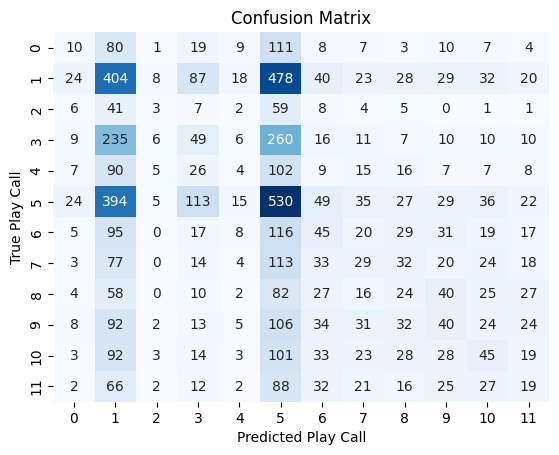

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Play Call')
plt.ylabel('True Play Call')
plt.title('Confusion Matrix')
plt.show()

In [29]:
target_names = np.array(sorted(y.unique()))
for idx, i in enumerate(target_names):
    print(f"{idx} - {i}")

0 - pass_left_deep
1 - pass_left_short
2 - pass_middle_deep
3 - pass_middle_short
4 - pass_right_deep
5 - pass_right_short
6 - run_left_end
7 - run_left_guard
8 - run_left_tackle
9 - run_right_end
10 - run_right_guard
11 - run_right_tackle


<h2>Increasing Number of Predictions</h2>
<p>Seeing if model can accurately predict the right play call within the top 'n' predictions</p>

In [ ]:
probabilities = model.predict_proba(X_test)
accuracy = []

for top_k in range(1, 13):
    count = 0
    for i, prob in enumerate(probabilities):
        # Get the indices of the top 3 classes based on probabilities
        top_indices = np.argsort(prob)[::-1][:top_k]
        top_classes = target_names[top_indices]
        top_probs = prob[top_indices]

        if(y_test[i] in top_indices):
            count +=1

    accuracy.append(count / len(y_test))

['pass_left_deep' 'pass_left_short' 'pass_middle_deep' 'pass_middle_short'
 'pass_right_deep' 'pass_right_short' 'run_left_end' 'run_left_guard'
 'run_left_tackle' 'run_right_end' 'run_right_guard' 'run_right_tackle']


Text(0, 0.5, 'Accuracy')

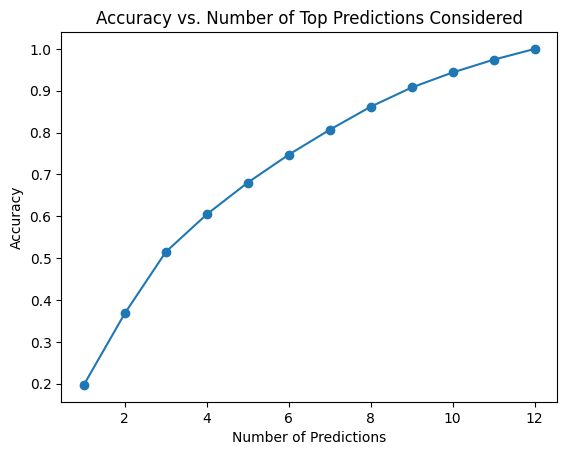

In [18]:
accuracy
plt.plot(range(1,13), accuracy, marker='o')
plt.title("Accuracy vs. Number of Top Predictions Considered")
plt.xlabel("Number of Predictions")
plt.ylabel("Accuracy")

<h2>GridSearchCV</h2>

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,            
    scoring='accuracy',
    n_jobs=-1,          
    verbose=1
)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")
print("Best CV Score:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
criterion: gini
max_depth: 3
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 2
Best CV Score: 0.22212500000000004
Test Accuracy: 0.21466666666666667


<h2>Model Evaluation: Balancing Class Weights</h2>

In [21]:
from sklearn.preprocessing import LabelEncoder

#Setting up features and targets
X = pd.get_dummies(df_combined[game_situation + offensive + defensive])
y = df_combined["offensive_play"]
le = LabelEncoder()
y_enc = le.fit_transform(y)

#Splitting into test and train sets
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

#RFC Model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                   precision    recall  f1-score   support

   pass_left_deep       0.08      0.03      0.05       283
  pass_left_short       0.24      0.34      0.28      1199
 pass_middle_deep       0.07      0.02      0.04       124
pass_middle_short       0.15      0.09      0.11       629
  pass_right_deep       0.04      0.01      0.02       290
 pass_right_short       0.25      0.41      0.31      1312
     run_left_end       0.13      0.11      0.11       409
   run_left_guard       0.09      0.06      0.07       351
  run_left_tackle       0.13      0.10      0.11       341
    run_right_end       0.12      0.09      0.10       390
  run_right_guard       0.15      0.10      0.12       370
 run_right_tackle       0.10      0.06      0.08       302

         accuracy                           0.20      6000
        macro avg       0.13      0.12      0.12      6000
     weighted avg       0.17      0.20      0.18      6000



<h2>Model Evaluation: Scaling Features</h2>

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#Setting up features and targets
X = pd.get_dummies(df_combined[game_situation + offensive + defensive])
y = df_combined["offensive_play"]
le = LabelEncoder()
y_enc = le.fit_transform(y)

#Splitting into test and train sets
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

#Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#RFC Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                   precision    recall  f1-score   support

   pass_left_deep       0.07      0.03      0.04       269
  pass_left_short       0.23      0.34      0.27      1191
 pass_middle_deep       0.09      0.02      0.04       137
pass_middle_short       0.11      0.07      0.09       629
  pass_right_deep       0.05      0.01      0.02       296
 pass_right_short       0.25      0.41      0.31      1279
     run_left_end       0.13      0.10      0.11       402
   run_left_guard       0.13      0.08      0.10       367
  run_left_tackle       0.13      0.10      0.11       315
    run_right_end       0.13      0.08      0.10       411
  run_right_guard       0.13      0.08      0.10       392
 run_right_tackle       0.10      0.06      0.08       312

         accuracy                           0.20      6000
        macro avg       0.13      0.12      0.11      6000
     weighted avg       0.16      0.20      0.17      6000

